In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

Fontconfig warning: ignoring UTF-8: not a valid region tag
Matplotlib is building the font cache; this may take a moment.


In [3]:
# Number of records
n = 12000

# Generate timestamps
timestamps = pd.date_range(
    start="2026-07-01 00:00:00",
    periods=n,
    freq="min"
)

# Generate status labels
status = np.random.choice(
    ["Normal", "Warning", "Fault"],
    size=n,
    p=[0.80, 0.15, 0.05]
)

# Build dataframe
df = pd.DataFrame({
    "timestamp": timestamps,
    "latitude": 43.0731 + np.random.normal(0,0.001,n),
    "longitude": -89.4012 + np.random.normal(0,0.001,n),
    "lidar_distance": np.random.normal(8,2,n),
    "battery_soc": np.linspace(100,20,n)+np.random.normal(0,2,n),
    "wheel_torque_1": np.random.normal(30,5,n),
    "wheel_torque_2": np.random.normal(30,5,n),
    "wheel_torque_3": np.random.normal(30,5,n),
    "wheel_torque_4": np.random.normal(30,5,n),
    "temperature": np.random.normal(24,4,n),
    "status": status
})

df.head()

,timestamp,latitude,longitude,lidar_distance,battery_soc,wheel_torque_1,wheel_torque_2,wheel_torque_3,wheel_torque_4,temperature,status
0,2026-07-01 00:00:00,43.072474,-89.400668,6.214978,101.499580,30.498199,27.707335,27.063768,29.265164,26.144969,Normal
1,2026-07-01 00:01:00,43.073330,-89.401182,2.904787,101.481014,31.638698,30.454532,24.826910,30.484939,27.499129,Fault
2,2026-07-01 00:02:00,43.073878,-89.401202,6.187738,98.925882,34.718033,29.222000,31.708100,32.937053,18.317683,Normal
3,2026-07-01 00:03:00,43.072368,-89.402706,5.984263,100.572100,36.340124,17.562884,36.368883,29.765023,23.060746,Normal
4,2026-07-01 00:04:00,43.073881,-89.402177,6.773406,102.499250,30.074116,27.359921,33.890405,34.695564,23.604358,Normal


In [4]:
# GPS missing
gps_missing = np.random.choice(df.index,size=int(0.03*n),replace=False)

df.loc[gps_missing,["latitude","longitude"]] = np.nan

# LiDAR saturation
lidar_bad = np.random.choice(df.index,size=int(0.02*n),replace=False)

df.loc[lidar_bad,"lidar_distance"] = 30

# Torque spikes
torque_bad = np.random.choice(df.index,size=int(0.05*n),replace=False)

for col in [
    "wheel_torque_1",
    "wheel_torque_2",
    "wheel_torque_3",
    "wheel_torque_4"
]:
    df.loc[torque_bad,col]+=np.random.normal(40,10,len(torque_bad))

df.head()

,timestamp,latitude,longitude,lidar_distance,battery_soc,wheel_torque_1,wheel_torque_2,wheel_torque_3,wheel_torque_4,temperature,status
0,2026-07-01 00:00:00,43.072474,-89.400668,6.214978,101.499580,30.498199,27.707335,27.063768,29.265164,26.144969,Normal
1,2026-07-01 00:01:00,43.073330,-89.401182,2.904787,101.481014,31.638698,30.454532,24.826910,30.484939,27.499129,Fault
2,2026-07-01 00:02:00,43.073878,-89.401202,30.000000,98.925882,34.718033,29.222000,31.708100,32.937053,18.317683,Normal
3,2026-07-01 00:03:00,43.072368,-89.402706,5.984263,100.572100,36.340124,17.562884,36.368883,29.765023,23.060746,Normal
4,2026-07-01 00:04:00,43.073881,-89.402177,6.773406,102.499250,30.074116,27.359921,33.890405,34.695564,23.604358,Normal


In [5]:
df.to_csv("../data/synthetic_rover_data.csv",index=False)

print("Dataset saved successfully!")

Dataset saved successfully!


In [6]:
df.head()
df.tail()
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   timestamp       12000 non-null  datetime64[us]
 1   latitude        11640 non-null  float64       
 2   longitude       11640 non-null  float64       
 3   lidar_distance  12000 non-null  float64       
 4   battery_soc     12000 non-null  float64       
 5   wheel_torque_1  12000 non-null  float64       
 6   wheel_torque_2  12000 non-null  float64       
 7   wheel_torque_3  12000 non-null  float64       
 8   wheel_torque_4  12000 non-null  float64       
 9   temperature     12000 non-null  float64       
 10  status          12000 non-null  str           
dtypes: datetime64[us](1), float64(9), str(1)
memory usage: 1.0 MB


,timestamp,latitude,longitude,lidar_distance,battery_soc,wheel_torque_1,wheel_torque_2,wheel_torque_3,wheel_torque_4,temperature
count,12000,11640.000000,11640.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,2026-07-05 03:59:30,43.073110,-89.401209,8.445379,59.987492,32.071983,31.972417,32.021776,31.963458,24.060806
min,2026-07-01 00:00:00,43.069178,-89.405666,-0.590782,15.861387,9.211331,7.685157,12.865085,11.474250,8.869538
25%,2026-07-03 01:59:45,43.072435,-89.401899,6.681359,40.062074,26.893524,26.827698,26.912750,26.841151,21.362990
50%,2026-07-05 03:59:30,43.073115,-89.401207,8.068789,59.976382,30.495946,30.284356,30.365038,30.260281,24.073571
75%,2026-07-07 05:59:15,43.073789,-89.400526,9.457575,79.983852,34.124655,34.016493,34.001953,34.034340,26.722810
max,2026-07-09 07:59:00,43.077579,-89.397472,30.000000,104.255163,102.605064,101.599151,102.893274,100.512669,40.808104
std,NaN,0.001004,0.000996,3.655411,23.180335,10.167552,10.273012,10.222317,10.329034,3.996021


In [ ]:
df.isnull().sum()

timestamp           0
latitude          360
longitude         360
lidar_distance      0
battery_soc         0
wheel_torque_1      0
wheel_torque_2      0
wheel_torque_3      0
wheel_torque_4      0
temperature         0
status              0
dtype: int64

In [8]:
(df.isnull().sum() / len(df) * 100).round(2)

timestamp         0.0
latitude          3.0
longitude         3.0
lidar_distance    0.0
battery_soc       0.0
wheel_torque_1    0.0
wheel_torque_2    0.0
wheel_torque_3    0.0
wheel_torque_4    0.0
temperature       0.0
status            0.0
dtype: float64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df["battery_soc"].describe()

count    12000.000000
mean        59.987492
std         23.180335
min         15.861387
25%         40.062074
50%         59.976382
75%         79.983852
max        104.255163
Name: battery_soc, dtype: float64

In [11]:
df["battery_soc"].describe()

count    12000.000000
mean        59.987492
std         23.180335
min         15.861387
25%         40.062074
50%         59.976382
75%         79.983852
max        104.255163
Name: battery_soc, dtype: float64

In [12]:
df["status"].value_counts()

status
Normal     9613
Warning    1822
Fault       565
Name: count, dtype: int64

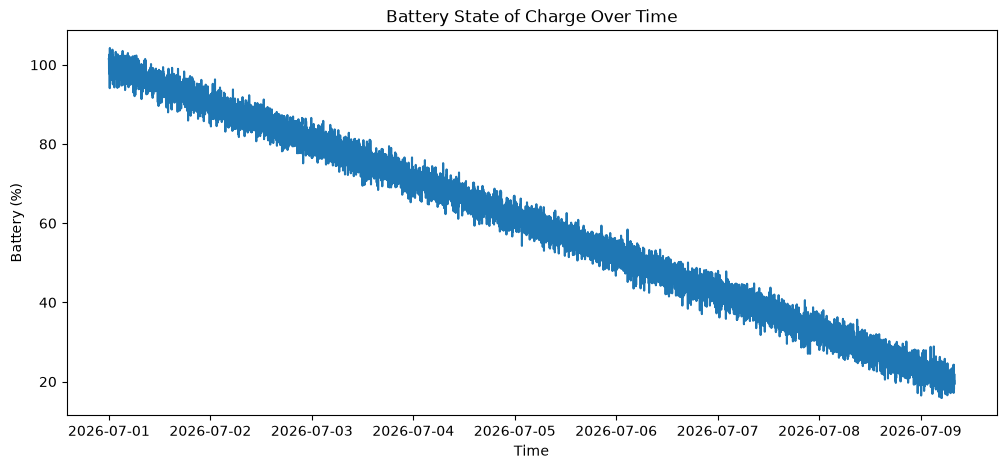

In [13]:
plt.figure(figsize=(12,5))

plt.plot(df["timestamp"], df["battery_soc"])

plt.title("Battery State of Charge Over Time")

plt.xlabel("Time")

plt.ylabel("Battery (%)")

plt.show()

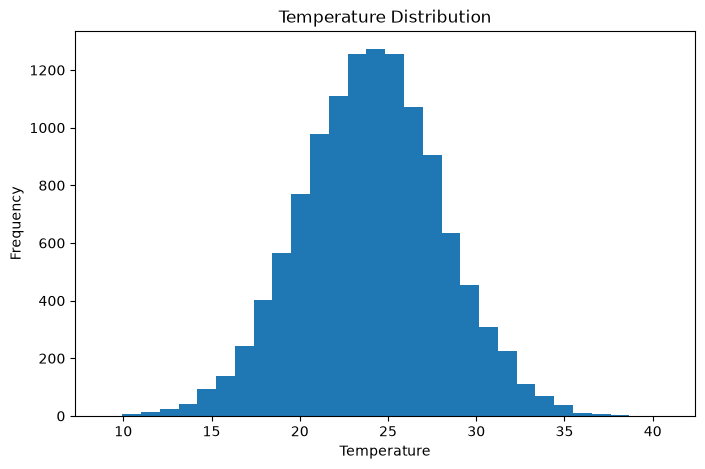

In [14]:
plt.figure(figsize=(8,5))

plt.hist(df["temperature"], bins=30)

plt.title("Temperature Distribution")

plt.xlabel("Temperature")

plt.ylabel("Frequency")

plt.show()

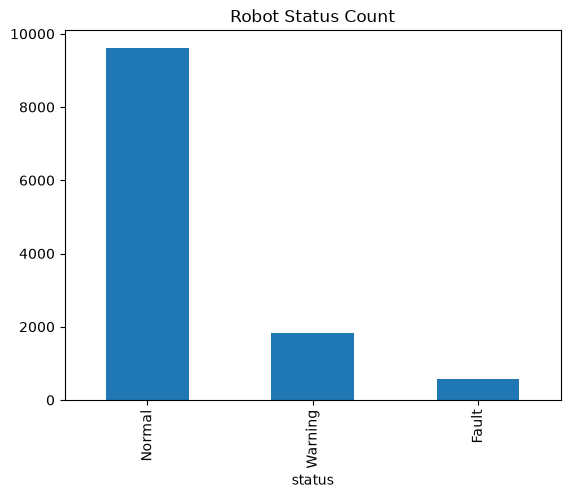

In [15]:
df["status"].value_counts().plot(kind="bar")

plt.title("Robot Status Count")

plt.show()

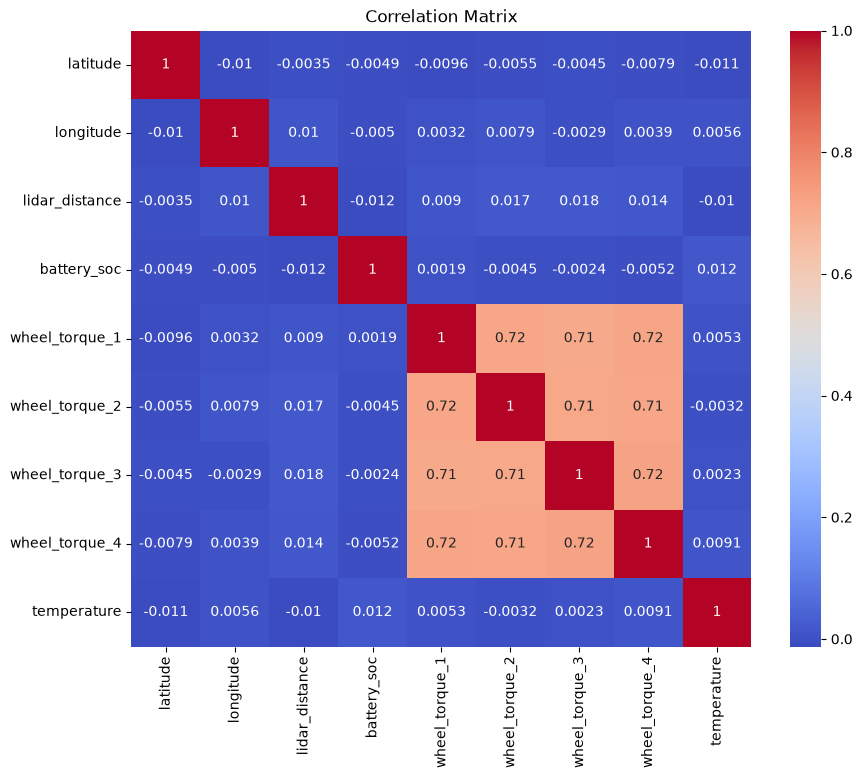

In [16]:
corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(10,8))

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

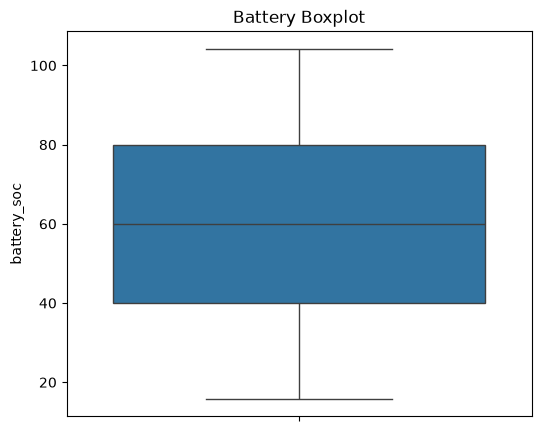

In [17]:
plt.figure(figsize=(6,5))

sns.boxplot(y=df["battery_soc"])

plt.title("Battery Boxplot")

plt.show()

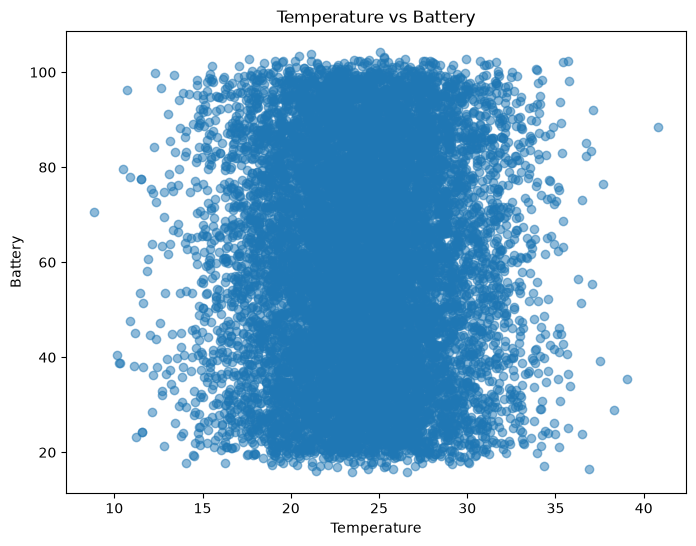

In [18]:
plt.figure(figsize=(8,6))

plt.scatter(df["temperature"],
            df["battery_soc"],
            alpha=0.5)

plt.xlabel("Temperature")

plt.ylabel("Battery")

plt.title("Temperature vs Battery")

plt.show()

# Week 2 EDA Summary

## Key Findings

- The dataset contains 12,000 simulated robot records.
- GPS has approximately 3% missing values.
- Battery State of Charge gradually decreases over time, which matches expected robot behavior.
- The majority of robot operations are labeled as "Normal", with only a small percentage classified as "Fault".
- Wheel torque contains several injected spikes to simulate abnormal operating conditions.
- The correlation analysis shows relationships among several sensor variables and can support future predictive modeling.